In [55]:
import torch
import statsmodels.api as sms
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from pyro.contrib.gp.kernels import Linear, Matern32, Periodic, Product, Sum
from statsmodels.tsa.stattools import adfuller

from generators.probabilistic_generator import Generator
from models.deep_probabilistic import MNCASTLE
from models.nonconv_opt import SSCASTLE, MSCASTLE

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [28]:
sns.set_context('talk')
plt.rcParams['text.usetex'] = True

# Generate synthetic data

In [4]:
N=3
T=512
density=.5
multiscale=.5
nonstationarity=.5

one = torch.ones(1)
zero = torch.zeros(1)

kern0 = Linear(1, one)
kern1= Matern32(1, one, 1/nonstationarity*one)
kern2= Periodic(1, one, 1/nonstationarity*one, 1/nonstationarity*one)

Kernel = Sum(Product(kern0, kern1), kern2)

In [5]:
gen = Generator(N=N, T=T, multiscale=multiscale, nonstationarity=nonstationarity, density=density, kernel=Kernel)
X=gen.generate()

In [25]:
print(r'Causal ordering={}; Total number of time scales J={}.'.format(gen.ordering.numpy(), gen.J.item()))

Causal ordering=[2 0 1]; Total number of time scales J=4.


In [26]:
data=pd.DataFrame(X.numpy(), columns=["1","2","3"])
data

,1,2,3
0,-1.635510,1.954813,0.475502
1,2.894865,0.914324,-2.344464
2,2.873907,2.186971,1.678390
3,4.391842,1.311385,0.717242
4,-0.141331,2.122834,-2.334531
...,...,...,...
507,-3.501809,-8.822906,2.078818
508,-0.996503,-8.342526,1.817277
509,6.959195,12.880344,0.058471
510,6.775802,17.266525,-2.255635


# Plot MN-DAG

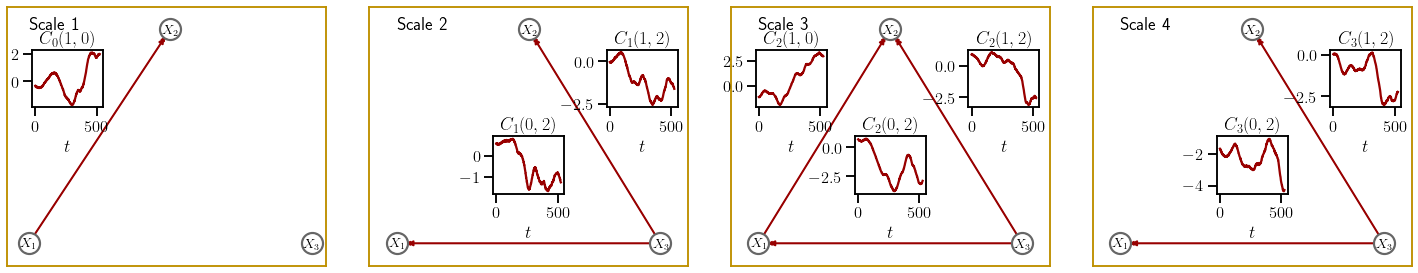

In [69]:
#if you do not set N=3,
#then change the code below accordingly
#in order to get proper plots

subfig_dict = {(0,1):[0.17, 0.65, .2, .2],(0,2):[0.45, 0.35, .2, .2],(1,2):[0.77, 0.65, .2, .2]}

fig = plt.figure(constrained_layout=True, figsize=(5*int(gen.J),4))

subfigs = fig.subfigures(1, gen.J.item())

for j, subfig in enumerate(subfigs.flat):
    ax1=subfig.add_axes([0.1, 0.1, .9, .9])
    plt.setp(ax1.spines.values(), color='#BF9000')
    plt.setp([ax1.get_xticklines(), ax1.get_yticklines()], color='#BF9000')
    
    G=nx.from_numpy_matrix(gen.C[j,0].numpy().T, create_using=nx.DiGraph)
    nx.draw_networkx(G, pos={0:(0,0), 1:(.5,1), 2:(1,0)}, with_labels=False, node_color='#666666', edge_color='#980000', width=2, node_size=450, linewidths=2, ax=ax1)
    nx.draw_networkx(G, pos={0:(0,0), 1:(.5,1), 2:(1,0)}, with_labels=False, node_color='white', edge_color='#980000', node_size=300, ax=ax1)
    ax1.text(0,1.,s="Scale {}".format(j+1))
    ax1.text(-.03,-.02,s="$X_{1}$", fontsize=14, fontweight='bold')
    ax1.text(.97,-.02,s="$X_{3}$", fontsize=14, fontweight='bold')
    ax1.text(.47,.98,s="$X_{2}$", fontsize=14, fontweight='bold')

    idxs = torch.nonzero(gen.C[j,0,...], as_tuple=False)

    axs = []
    for row in range(idxs.shape[0]):
        key = tuple(idxs[row].sort()[0].numpy())
        nodes = tuple(idxs[row].numpy())
        axs.append(subfig.add_axes(subfig_dict[key]))
        axs[row].set_xlabel("$t$")
        axs[row].set_title(r"$C_{}{}$".format(j,nodes))
        sns.lineplot(data=gen.C[j,:,nodes[0], nodes[1]], color='#980000', ax=axs[row])
    
plt.show()

# Statistics of data

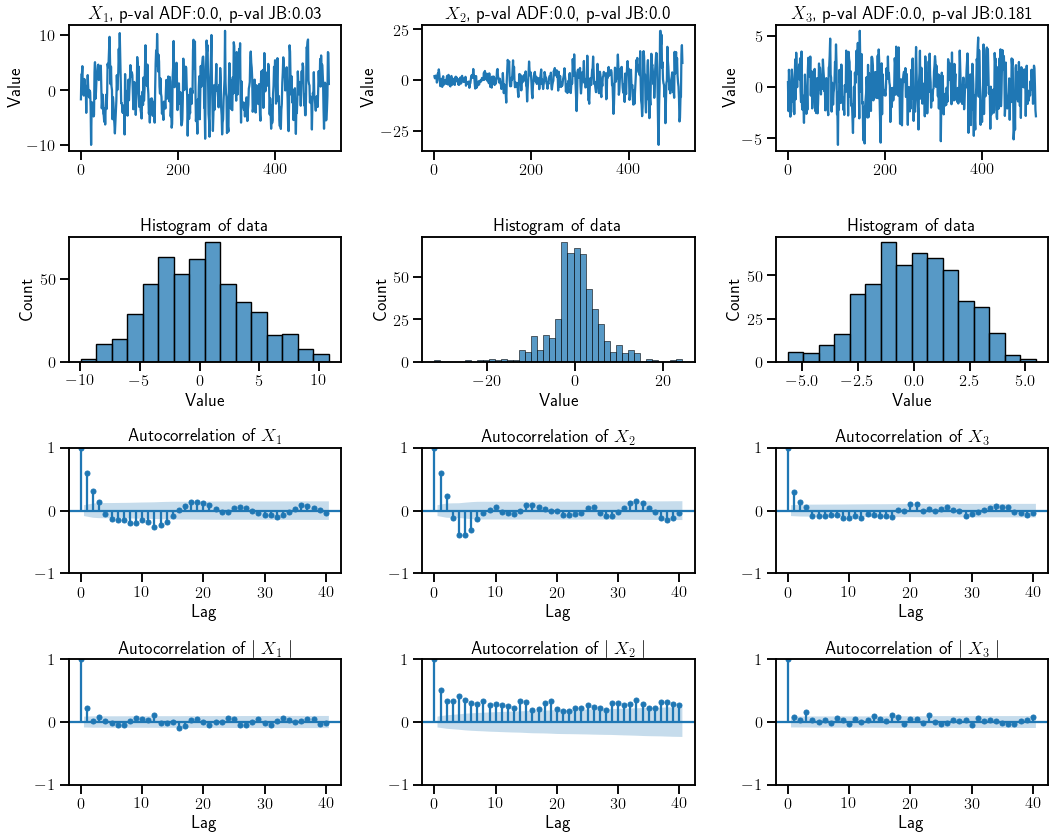

In [29]:
fig, ax = plt.subplots(4,3, figsize=(15,12))

for n in range(N): 
    sns.lineplot(data=data.iloc[:,n], ax=ax[0,n])
    ax[0,n].set_ylabel(r'Value')
    ax[0,n].set_title(r'$X_{}$, p-val ADF:{}, p-val JB:{}'.format(n+1, round(adfuller(data.iloc[:,n])[1],3), round(sms.stats.jarque_bera(data.iloc[:,n])[1],3)))
    sns.histplot(data.iloc[:,n], ax=ax[1,n])
    ax[1,n].set_title(r'Histogram of data')
    ax[1,n].set_xlabel(r'Value')
    sms.graphics.tsa.plot_acf(data.iloc[:,n], lags=40, ax=ax[2,n])
    ax[2,n].set_title(r"Autocorrelation of $X_{}$".format(n+1))
    ax[2,n].set_xlabel(r'Lag')
    sms.graphics.tsa.plot_acf(data.iloc[:,n].abs(), lags=40, ax=ax[3,n])
    ax[3,n].set_title(r"Autocorrelation of $\mid X_{} \mid$".format(n+1))
    ax[3,n].set_xlabel(r'Lag')

plt.tight_layout()
plt.show()